In [1]:
# using Pkg; Pkg.add("DynamicalSystems")
using DynamicalSystems
# Define Lorenz system: equations take the current state "u"
# with parameters "p" at time "t" and return an SVector
# with the derivatives.
@inline @inbounds function lorenz(u, p, t)
    alpha = p[1]; rho = p[2]; beta = p[3]
    du1 = alpha*(u[2]-u[1])
    du2 = u[1]*(rho-u[3])-u[2]
    du3 = u[1]*u[2] - beta*u[3]
    return SVector{3}(du1, du2, du3)
end
# A function for the Jacobian is useful but not necessary;
# If it is not given, automatic differentiation is used
@inline @inbounds function lorenz_jac(u, p, t)
    alpha, rho, beta = p
    J = @SMatrix [-alpha  alpha  0;
                  rho-u[3] (-1) (-u[1]);
                  u[2]   u[1]  -beta]
    return J
end
# typical chaotic initial condition:
u0 = [0.0, 10.0, 0.0]
# parameters with strange attractor:
p = [10, 28, 8/3]
# Create the dynamical system structure
ds = ContinuousDynamicalSystem(lorenz, u0, p, lorenz_jac)
# Calculate the full lyapunov spectrum by doing QR-decomposition 2000 times
# and evolving in between for 2.0 units of time
labdas = lyapunovspectrum(ds, 2000; dt = 2.0)

3-element Vector{Float64}:
   0.8898333844603599
  -0.0001372191046185643
 -14.556338956899742

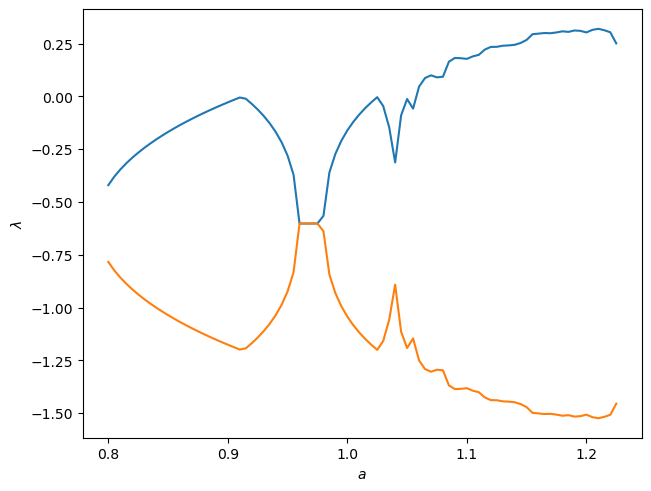

    Building Conda ─→ `C:\Users\jiangdonghua\.julia\scratchspaces\44cfe95a-1eb2-52ea-b672-e2afdf69b78f\6cdc8832ba11c7695f494c9d9a1c31e90959ce0f\build.log`
    Building PyCall → `C:\Users\jiangdonghua\.julia\scratchspaces\44cfe95a-1eb2-52ea-b672-e2afdf69b78f\4ba3651d33ef76e24fef6a598b63ffd1c5e1cd17\build.log`
   Resolving package versions...
  No Changes to `C:\Users\jiangdonghua\.julia\environments\v1.7\Project.toml`
  No Changes to `C:\Users\jiangdonghua\.julia\environments\v1.7\Manifest.toml`


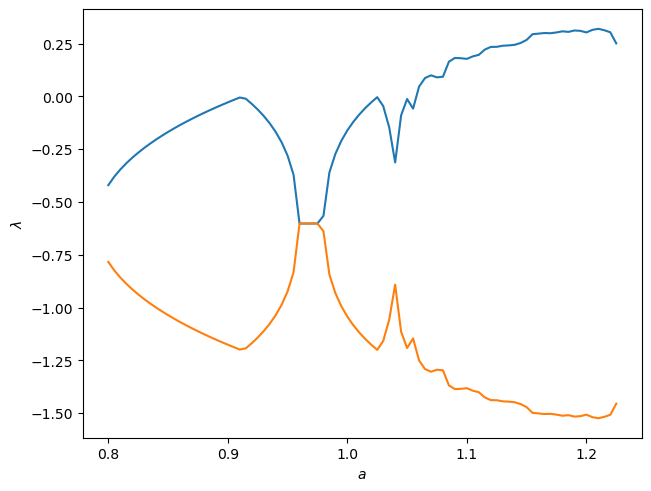

In [4]:
# using Pkg; ENV["PYTHON"]="pythoncommand"; Pkg.build("PyCall"); Pkg.add("PyPlot")
using DynamicalSystems, PyPlot
he = Systems.henon()
as = 0.8:0.005:1.225; 
labdas = zeros(length(as), 2)
for (i, a) in enumerate(as)
    set_parameter!(he, 1, a)
    labdas[i, :] .= lyapunovspectrum(he, 10000; Ttr = 500)
end
fig = figure()
plot(as, labdas); xlabel("\$a\$"); ylabel("\$\\lambda\$")
fig.tight_layout(pad = 0.3); 
fig